In [1]:
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import os

In [2]:
# Load metadata
metadata = pd.read_csv('../data/raw/brugada-huca-1.0.0/metadata.csv')

In [3]:
# Display basic statistics
print(metadata.head())
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


In [4]:
# Column names
print(metadata.columns)

Index(['patient_id', 'basal_pattern', 'sudden_death', 'brugada'], dtype='str')


In [5]:
# Number of unique values in each column
metadata[['basal_pattern', 'sudden_death', 'brugada']].nunique()

basal_pattern    2
sudden_death     2
brugada          3
dtype: int64

In [6]:
# Target distribution
print(metadata['brugada'].value_counts())

brugada
0    287
1     69
2      7
Name: count, dtype: int64


In [7]:
# Entries where target=2 
print(metadata[metadata['brugada'] == 2])

     patient_id  basal_pattern  sudden_death  brugada
30       460919              0             0        2
51       571723              1             1        2
75       822108              1             0        2
79       841212              0             0        2
104      945345              1             0        2
242     1290807              1             0        2
316     3016396              0             0        2


In [8]:
# Search for missing records
missing_records = []

for patient_id in metadata['patient_id'].astype(str):
    if not os.path.exists(f'../data/raw/brugada-huca-1.0.0/files/{patient_id}/{patient_id}.hea'):
        missing_records.append(patient_id)

print(f'Missing records: {len(missing_records)}')

Missing records: 0


In [9]:
# Load metadata_dict
metadata_dict = pd.read_csv('../data/raw/brugada-huca-1.0.0/metadata_dictionary.csv')
print(metadata_dict)

        Variable                                        Description
0     patient_id                      An identifier for the subject
1      diagnosis                       The diagnosis of the subject
2   sudden_death  Whether the subject has had a sudden death or not
3  basal_pattern    Whether the baseline ECG is pathological or not
4        brugada                       The diagnosis of the subject


In [10]:
# Read a single patient's ECG
patient_id = '188981'
record = wfdb.rdrecord(f'../data/raw/brugada-huca-1.0.0/files/{patient_id}/{patient_id}')

In [11]:
# Access the signal data
signals = record.p_signal       # Signal array (samples × leads)
lead_names = record.sig_name    # Lead names (I, II, III, aVR, aVL, aVF, V1–V6)
sampling_freq = record.fs       # Sampling frequency (100 Hz)

print('Signal array (samples × leads):', signals.shape)
print('Lead names: ' + str(lead_names))
print(f'Sampling frequency: {sampling_freq}')

Signal array (samples × leads): (1200, 12)
Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Sampling frequency: 100


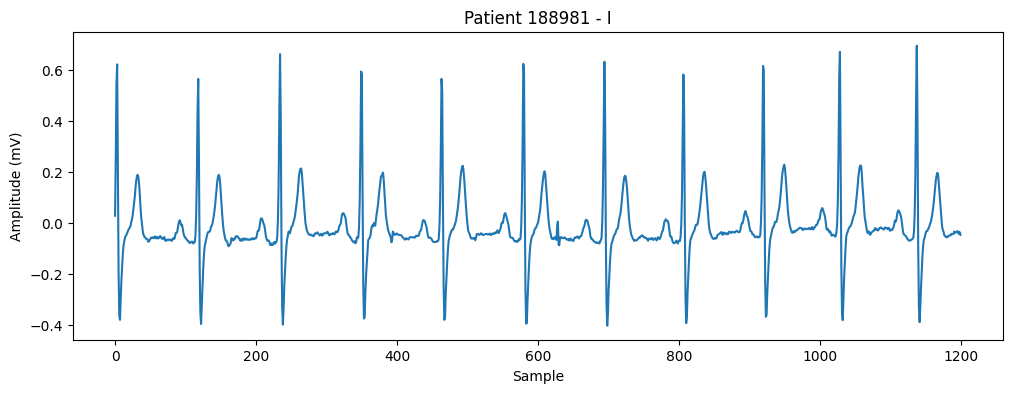

In [12]:
# Plot a specific lead
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])  # Plot first lead (Lead I)
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()